## Question 1: Regression Analysis & Data Preprocessing – Business and Housing Use Cases

### Scenario

You are working as a data analyst for a **real estate team** that wants to predict house prices using multiple factors.

You must clean, preprocess, analyze, and model the data appropriately.

### Datasets

* **House Prices Dataset (Multiple Linear Regression – Kaggle)**
  [https://www.kaggle.com/datasets/camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

### Tasks

1. Perform **EDA** on datasets.
2. Apply required **data preprocessing** steps:

   * Handling missing values
   * Feature encoding (if applicable)
   * Feature scaling
4. Build a **Multiple Linear Regression** model for the housing dataset.
5. Interpret regression coefficients in real-world terms.
6. Evaluate model using **R²**, **MSE**, and residual analysis.
7. State and verify assumptions of linear regression.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv("housing.csv", compression="zip")

In [52]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [53]:
df.shape

(20640, 10)

In [54]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

1. Exploratory Data Analysis — EDA

In [55]:
# Basic Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [56]:
# Statistical Summary

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [57]:
# Check Missing Values

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [58]:
# Percentage of Missing Values

df.isnull().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [59]:
# Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [60]:
# Analyze Categorical Data
# ocean_proximity is a categorical variable, so we can analyze its distribution using value_counts().

df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

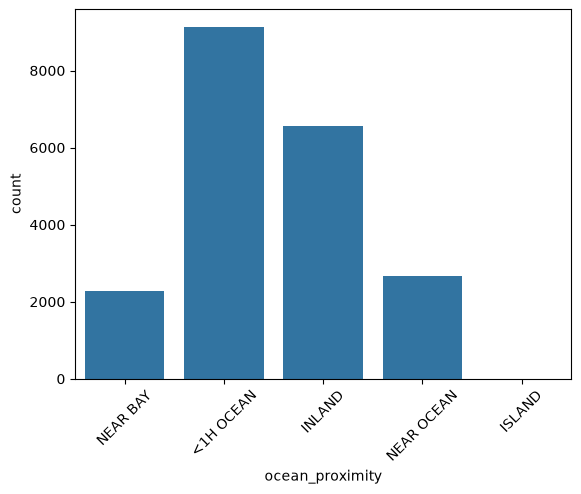

In [61]:
# Visualize Categorical Data

sns.countplot(data=df, x="ocean_proximity")
plt.xticks(rotation=45)
plt.show()

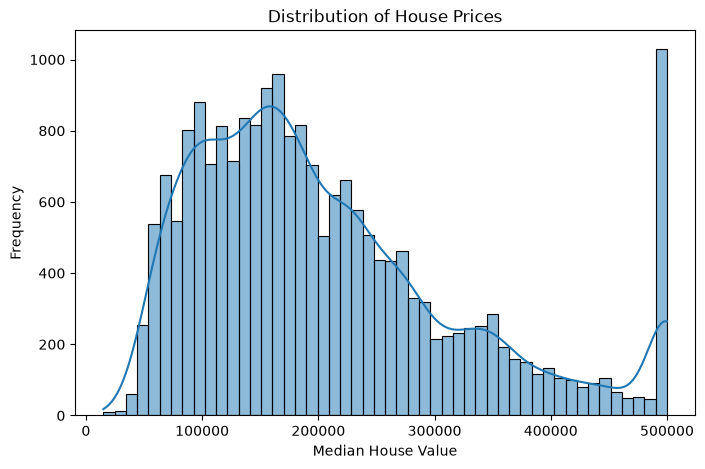

In [62]:
# Distribution of House Prices
# median_house_value is the target variable, so we can analyze its distribution using a histogram.

plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

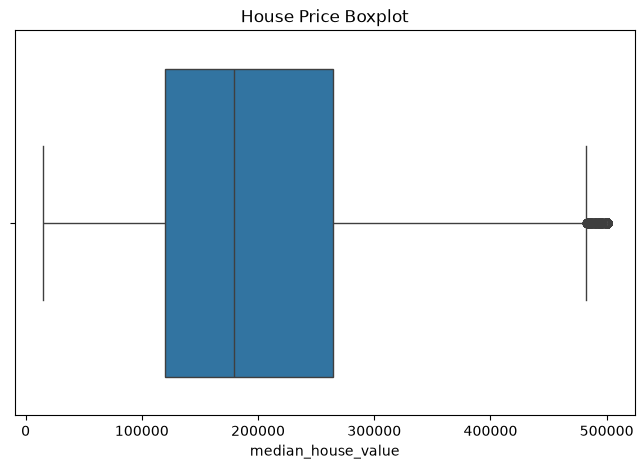

In [63]:
# box plot for median_house_value to visualize the distribution and identify any outliers.

plt.figure(figsize=(8,5))
sns.boxplot(x=df["median_house_value"])
plt.title("House Price Boxplot")
plt.show()

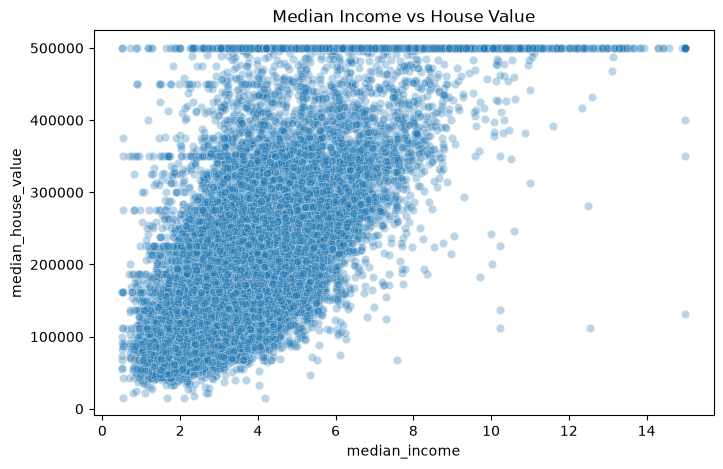

In [64]:
# Visualize Relationship Between Median Income and House Value

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value",
    alpha=0.3
)

plt.title("Median Income vs House Value")
plt.show()

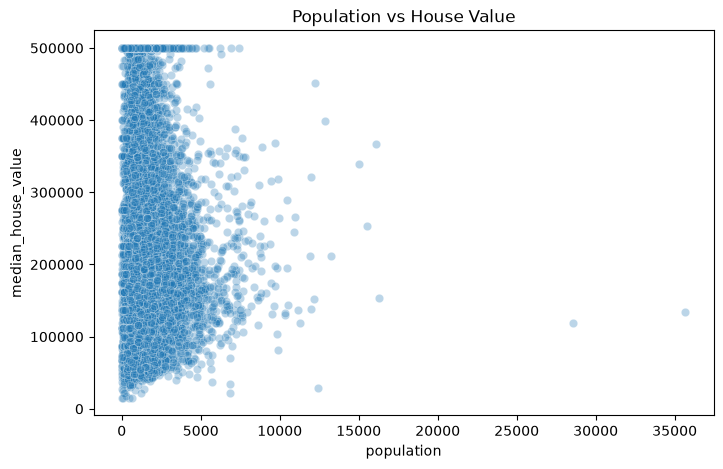

In [65]:
# visualize Relationship between house value and population using a scatter plot.

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="population",
    y="median_house_value",
    alpha=0.3
)

plt.title("Population vs House Value")
plt.show()

In [66]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=np.number)

In [67]:
numeric_df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


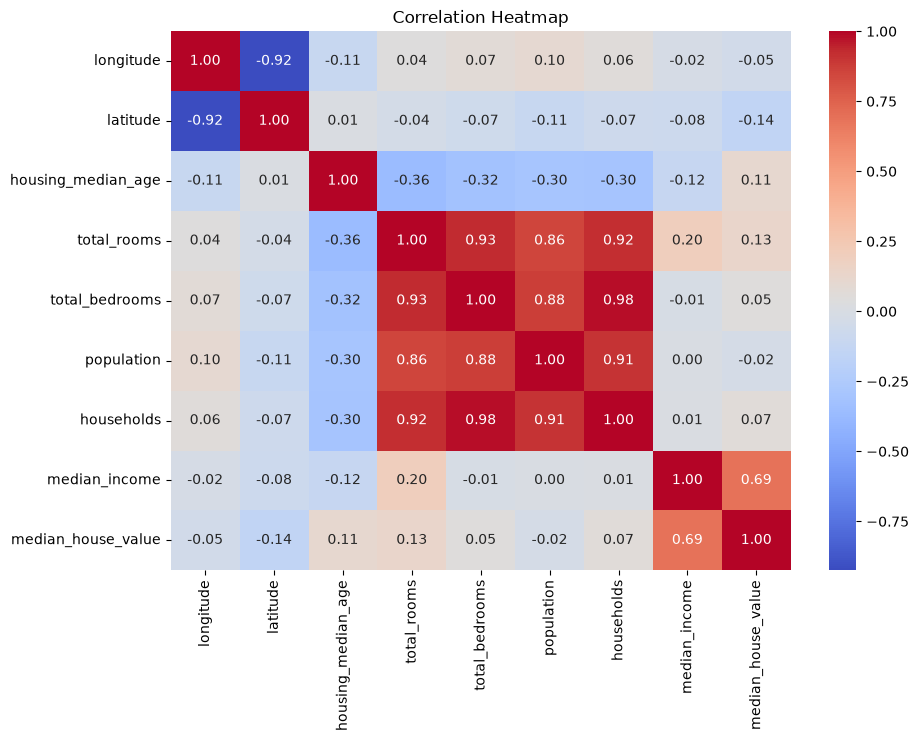

In [68]:
# visualize feature correlation using a heatmap.

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [69]:
# Data Preprocessing 
y = df["median_house_value"]

In [70]:
X = df.drop("median_house_value", axis=1)

In [71]:
# Handle Missing Values

X.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [72]:
X["total_bedrooms"] = X["total_bedrooms"].fillna(
    X["total_bedrooms"].median()
)

In [73]:
X.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [74]:
# Separate Numerical and Categorical Features

numeric_features = X.select_dtypes(
    include=np.number
).columns

categorical_features = X.select_dtypes(
    exclude=np.number
).columns

In [75]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='str')

Categorical features:
Index(['ocean_proximity'], dtype='str')


In [76]:
# feature encoding using ColumnTransformer to apply StandardScaler to numerical features and OneHotEncoder to categorical features.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [77]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
# Preprocess the Data
X_train_processed = preprocessor.fit_transform(X_train)

In [79]:
# Preprocess the Test Data
X_test_processed = preprocessor.transform(X_test)

In [80]:
# Build Multiple Linear Regression Model
model = LinearRegression()

In [81]:
# Train the Model
model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-53826.65,-54415.7 , 13889.87,...,117198.49,-24063.23,-15495.44]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.388e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[253.96,181.09,133.6 ,..., 15.43, 2.23, 0. ]"


In [82]:
# Make Predictions
y_pred = model.predict(X_test_processed)

In [83]:
# view the first 10 predictions
print(y_pred[:10])

[ 54055.44889898 124225.33893718 255489.37949166 268002.43156919
 262769.43481568 139606.3039556  290665.42391417 228264.87637529
 256506.78561005 407923.85843486]


In [84]:
# compare the actual and predicted values for the first 10 samples in the test set.
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
0,47700.0,54055.448899
1,45800.0,124225.338937
2,500001.0,255489.379492
3,218600.0,268002.431569
4,278000.0,262769.434816
5,158700.0,139606.303956
6,198200.0,290665.423914
7,157500.0,228264.876375
8,340000.0,256506.785610
9,446600.0,407923.858435


In [85]:
# Evaluate the Model R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6254240620553604


In [86]:
# Evaluate the Model Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 4908476721.156618


In [89]:
# Evaluate the Model Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 70060.5218447352


In [91]:
# Print All Evaluation Results
print("Model Evaluation")
print("----------------")
print("R²:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

Model Evaluation
----------------
R²: 0.6254240620553604
MSE: 4908476721.156618
RMSE: 70060.5218447352


In [92]:

feature_names = preprocessor.get_feature_names_out()

In [96]:
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,num__longitude,-53826.648016
1,num__latitude,-54415.696144
2,num__housing_median_age,13889.866189
3,num__total_rooms,-13094.251162
4,num__total_bedrooms,43068.181842
5,num__population,-43403.432427
6,num__households,18382.196324
7,num__median_income,75167.774766
8,cat__ocean_proximity_<1H OCEAN,-18926.582862
9,cat__ocean_proximity_INLAND,-58713.239023


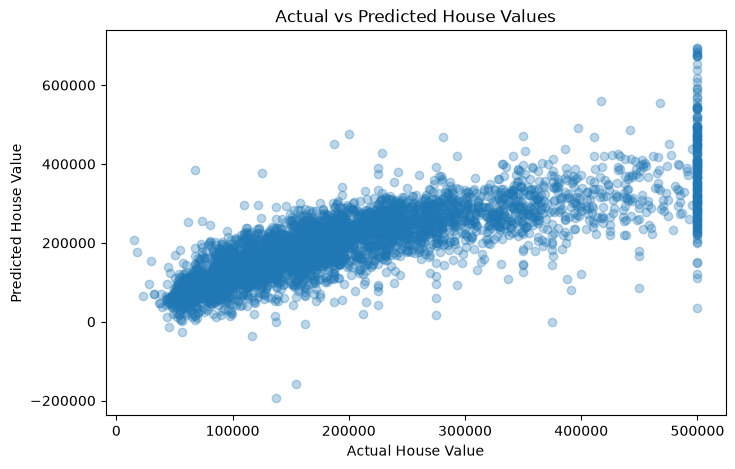

In [97]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [98]:
residuals = y_test - y_pred

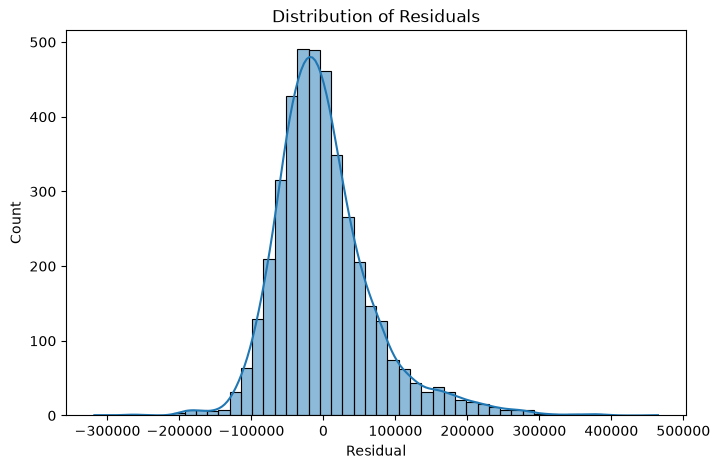

In [99]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=50, kde=True)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

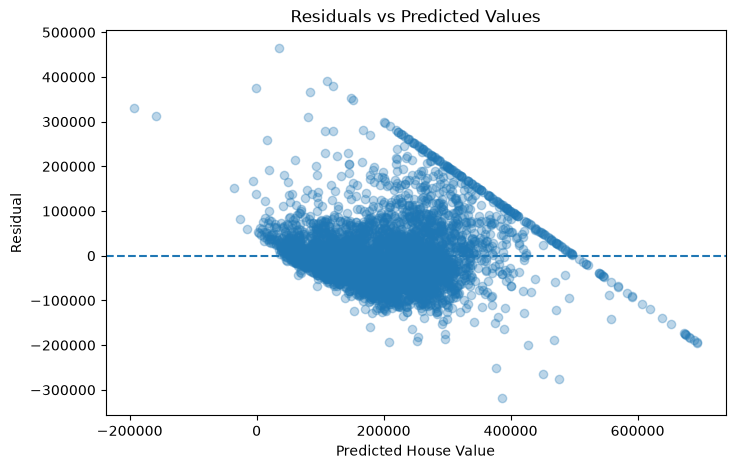

In [100]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

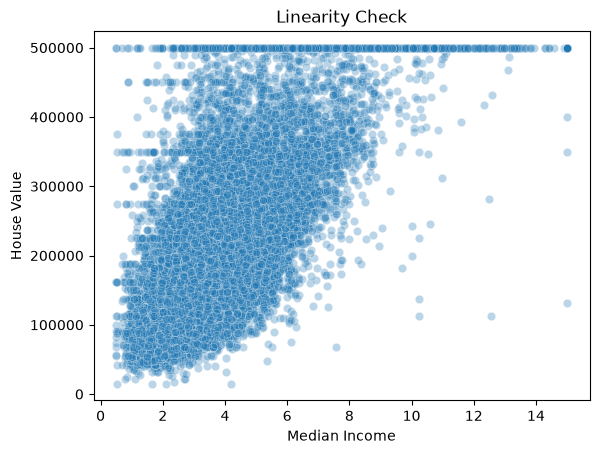

In [101]:
sns.scatterplot(
    x=df["median_income"],
    y=df["median_house_value"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linearity Check")
plt.show()

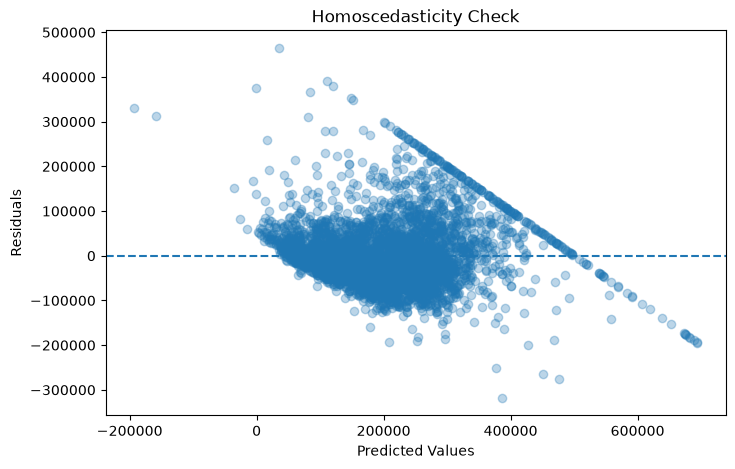

In [102]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")

plt.show()

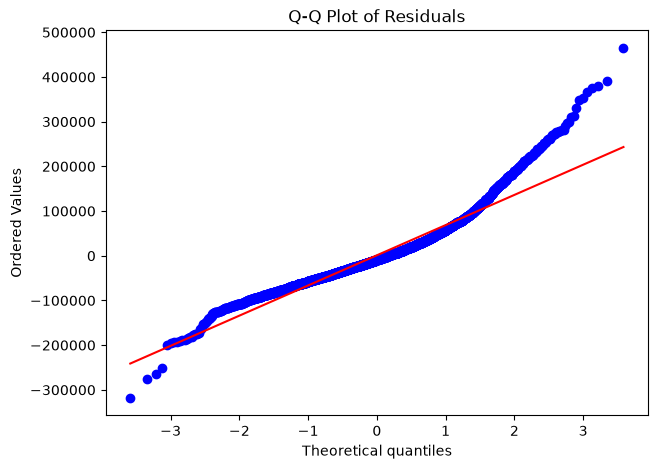

In [103]:
import scipy.stats as stats

plt.figure(figsize=(7,5))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")
plt.show()

In [1]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
X_vif = df.select_dtypes(include=np.number).drop(
    "median_house_value",
    axis=1
).dropna()

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif

LinAlgError: SVD did not converge